In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [72]:
# loading the dataset
df = pd.read_csv('../datasets/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [73]:
# getting dimensions
df.shape

(768, 9)

In [74]:
# basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [75]:
# statistical description
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [76]:
# null checks.
df.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Outcome          0
dtype: int64

In [77]:
# EDA

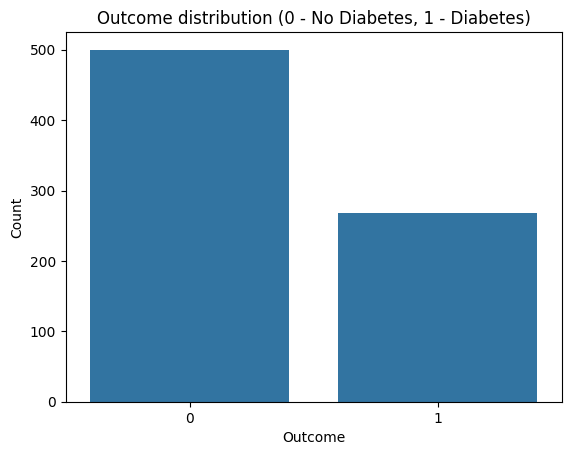

In [78]:
# checking the diabetes count
sns.countplot(x='Outcome', data=df)
plt.title('Outcome distribution (0 - No Diabetes, 1 - Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

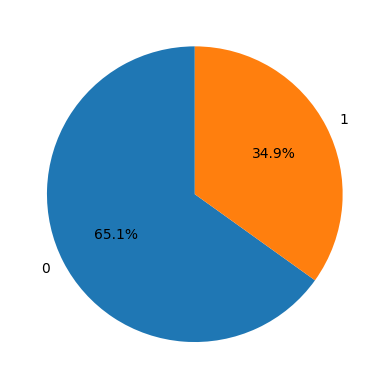

In [79]:
outcome_counts = df['Outcome'].value_counts()
plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

In [80]:
# data preparation.
X = df.drop(columns=['Outcome'], axis=1)
y = df['Outcome']

In [81]:
# scalling features
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [82]:
# data separation
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

In [83]:
# training model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [84]:
y_pred = model.predict(X_test)

In [85]:
# calculating metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
error = 1 - acc

print(f"accuracy: {acc}")
print(f"recall: {recall}")
print(f"precision: {precision}")
print(f"error: {error}")

accuracy: 0.6822916666666666
recall: 0.5217391304347826
precision: 0.5625
error: 0.31770833333333337


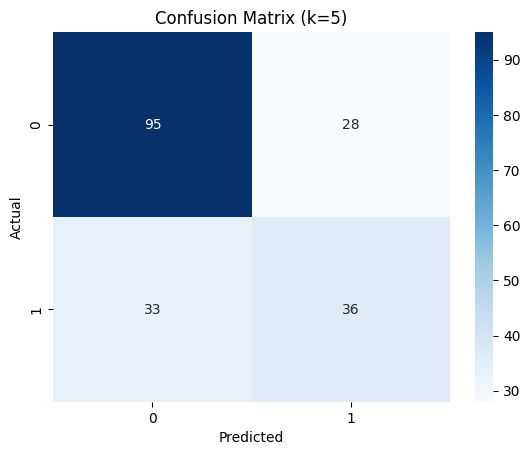

In [86]:
# display confusion matrix
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title('Confusion Matrix (k=5)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [101]:
# finding the best k
import math

acc_values = []
for i in range(1, 200):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    knn_pred = knn.predict(X_test)
    acc_values.append(accuracy_score(y_test, knn_pred))

max_accuracy = max(acc_values)
best_k = acc_values.index(max_accuracy) + 1
print(f"Maximum accuracy: {max_accuracy} with k: {best_k}")

Maximum accuracy: 0.765625 with k: 87


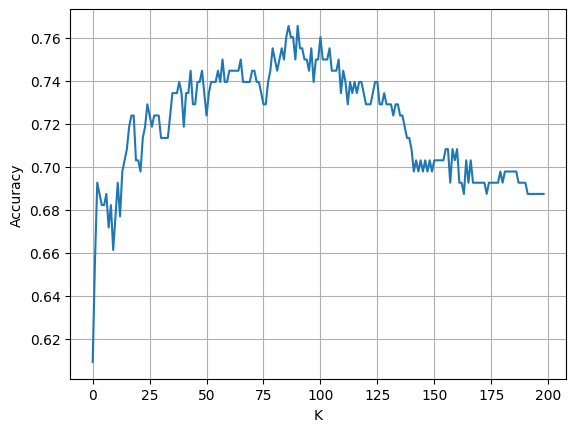

In [102]:
# plotting the accuracies
plt.plot(acc_values)
plt.xlabel('K')
plt.grid(True)
plt.ylabel('Accuracy')
plt.show()